In [1]:
import sys
import numpy as np
import pandas as pd
import sklearn

print(f"Python: {sys.version}")
print(f"Numpy:  {np.__version__}")
print(f"Pandas: {pd.__version__}")
print(f"Sklearn: {sklearn.__version__}")

Python: 3.10.19 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 16:41:31) [MSC v.1929 64 bit (AMD64)]
Numpy:  2.2.6
Pandas: 2.3.3
Sklearn: 1.7.2


In [2]:
import numpy as np

X = np.random.rand(100, 5)

print("Статистика по всей матрице:")
print(f"\nСреднее значение:  {X.mean()}")
print(f"\nСтандартное отклонение: {X.std()}")
print(f"\nМинимальное значение: {X.min()}")
print (f"\nМаксимальное значение: {X.max()}")

print("\nСтатистика по каждому столбцу:")
print(f"\nСреднее значение:  {X.mean(axis = 0)}")
print(f"\nСтандартное отклонение: {X.std(axis = 0)}")
print(f"\nМинимальное значение: {X.min(axis = 0)}")
print(f"\nМаксимальное значение: {X.max(axis = 0)}")

w = np.random.rand(5)
y = X @ w
print(f"\nРазмерность y: {y.shape}")

Статистика по всей матрице:

Среднее значение:  0.5077178613880278

Стандартное отклонение: 0.2829457289865996

Минимальное значение: 0.0006038246029920202

Максимальное значение: 0.9996882385411292

Статистика по каждому столбцу:

Среднее значение:  [0.48706008 0.56047416 0.52509873 0.48169762 0.48425871]

Стандартное отклонение: [0.28633131 0.27762543 0.26071224 0.30435617 0.27547582]

Минимальное значение: [0.0034242  0.01548114 0.00936459 0.00296958 0.00060382]

Максимальное значение: [0.99801526 0.99968824 0.99219665 0.99910546 0.99595288]

Размерность y: (100,)


In [3]:
import pandas as pd

columns = [f'feature_{i+1}' for i in range(5)]
df = pd.DataFrame(X, columns=columns)

df['target'] = y

print("Размер таблицы (shape):", df.shape)
print("\nПервые 5 строк (head):")
display(df.head())

print("\nСтатистическое описание (describe):")
display(df.describe())

print("\nПроверка пропусков:")
print(df.isna().sum())

# Фильтруем значения target выше среднего и сортируем по убыванию
mean_target = df['target'].mean()
filtered_df = df[df['target'] > mean_target].sort_values(by='target', ascending=False)

print("\nОтфильтрованные и отсортированные данные (первые 5 строк):")
display(filtered_df.head(5))

Размер таблицы (shape): (100, 6)

Первые 5 строк (head):


,feature_1,feature_2,feature_3,feature_4,feature_5,target
0,0.655822,0.388223,0.215208,0.679008,0.098880,1.402195
1,0.207448,0.999688,0.636199,0.584110,0.410398,1.586403
2,0.605785,0.684400,0.271708,0.164599,0.847407,1.346876
3,0.134008,0.977795,0.982754,0.999105,0.184901,2.068397
4,0.477464,0.881646,0.239583,0.752369,0.059762,1.447140



Статистическое описание (describe):


,feature_1,feature_2,feature_3,feature_4,feature_5,target
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,0.487060,0.560474,0.525099,0.481698,0.484259,1.552183
std,0.287774,0.279024,0.262026,0.305889,0.276864,0.400284
min,0.003424,0.015481,0.009365,0.002970,0.000604,0.460953
25%,0.264833,0.355414,0.328412,0.197857,0.214559,1.333129
50%,0.478419,0.560274,0.522502,0.480131,0.504371,1.509910
75%,0.697968,0.802982,0.753287,0.755700,0.719899,1.829905
max,0.998015,0.999688,0.992197,0.999105,0.995953,2.473266



Проверка пропусков:
feature_1    0
feature_2    0
feature_3    0
feature_4    0
feature_5    0
target       0
dtype: int64

Отфильтрованные и отсортированные данные (первые 5 строк):


,feature_1,feature_2,feature_3,feature_4,feature_5,target
45,0.989549,0.559157,0.636215,0.902450,0.670969,2.473266
6,0.770388,0.802151,0.499087,0.900017,0.852446,2.324689
98,0.880656,0.105545,0.696928,0.785188,0.891424,2.321983
66,0.973631,0.372206,0.757669,0.937585,0.059956,2.288553
41,0.340551,0.746523,0.760033,0.998295,0.685051,2.203903


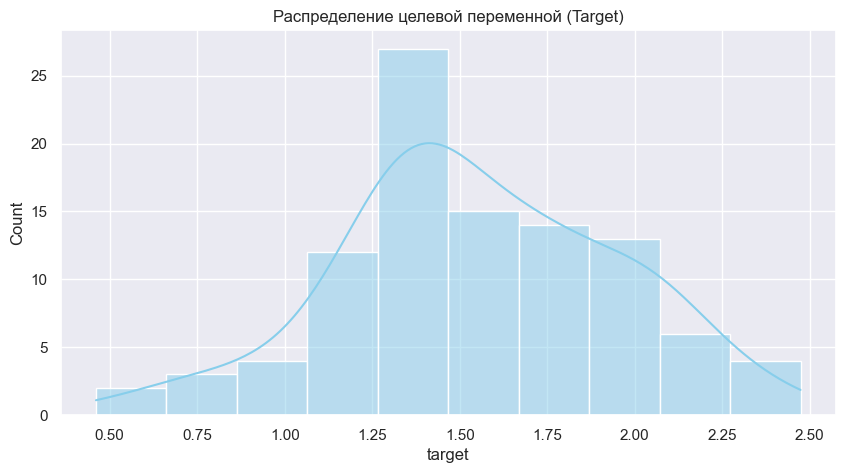

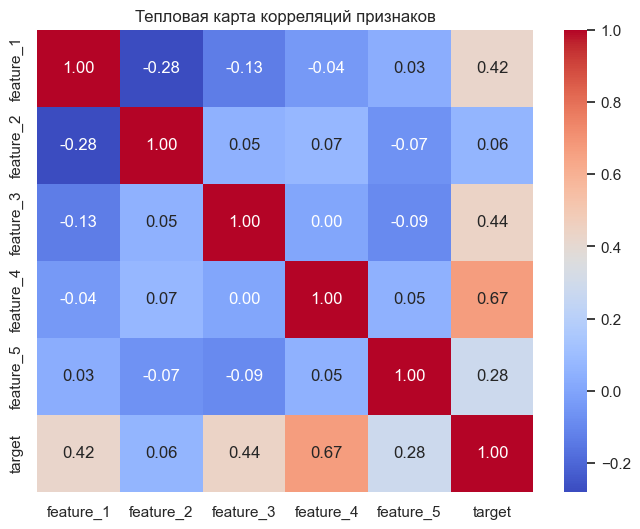

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme()

# 1. Гистограмма target
plt.figure(figsize=(10, 5))
sns.histplot(df['target'], kde=True, color='skyblue')
plt.title("Распределение целевой переменной (Target)")
plt.show()

# 2. Тепловая карта корреляций
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Тепловая карта корреляций признаков")
plt.show()